<h3>Exercise 5:</h3>
5.1

In [1]:
import matplotlib.pyplot as plt
import numpy as np

x0 = .2    # Initial condition x(0) = .2
h = .5     # Step size .5
tmax = 20  # End condition

# Define parameter sets
r, k = [1, 0.5], [1, 2]

def step(param_index, x):
    """ Takes one step of length h in the direction
    specified by the differential equation and returns
    the new x coordinate """
    func = r[param_index] * x * (1 - x/k[param_index])
    return x + h * func


def run(param_index):
    # Define two lists for x and t, and set the initial condition for x
    x, t = [x0], []
    
    # Perform the simulation by letting t advance from 0 to the
    # upper bound tmax + h, so that we include t = tmax.
    # Iterables are denoted with double letters (ex. tt)
    for tt in np.arange(0, tmax + h, h):
        t.append(tt) # Append current time for plotting
        
        # Don't add a new step for t = 0 to preserve
        # equal length for x and t
        if tt != 0: x.append(step(param_index, x[-1]))

    return t, x

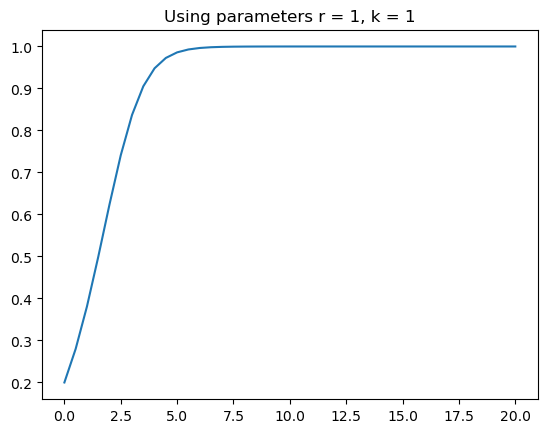

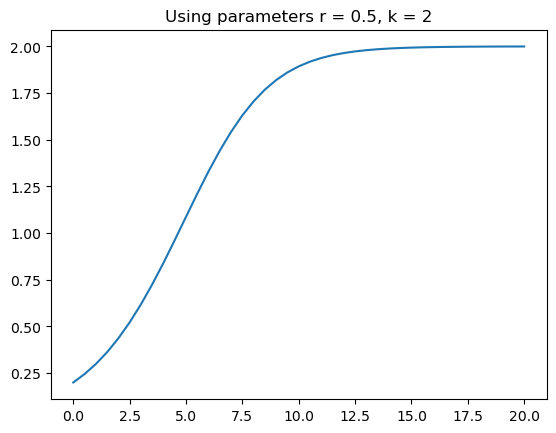

In [2]:
# Plot the results using each parameter set:
for ii in range(2):
    plt.title(f"Using parameters r = {r[ii]}, k = {k[ii]}")
    t, x = run(ii)
    plt.plot(t, x)
    plt.show()

<h3>5.2</h3>

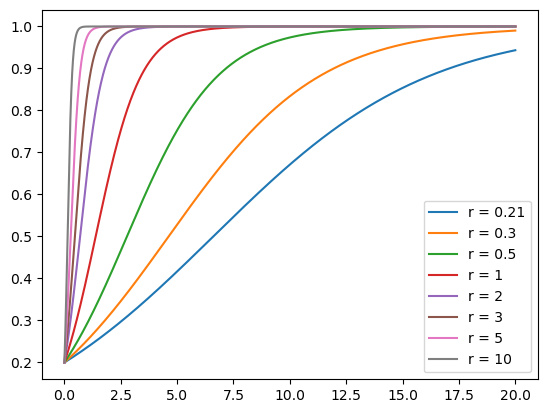

In [4]:
h /= 10 # We'll need a smaller step size for this plot
r, k = [0.21, .3, .5, 1, 2, 3, 5, 10], [1]*8

plt.title('')

for ii in range(8):
    t, x = run(ii)
    plt.plot(t, x, label = f'r = {r[ii]}')
plt.legend()

As specified in the exercise, the function starts at 0.2 and then it 
rises until the value k (horizontal asymptote) over a timeframe influenced by r. For larger 
values of r, the function rises to its maximum value more quickly and 
vice-versa.

<h3>Exercise 4</h3>
4.1

In [4]:
class Simulation:
    def __init__(self, I, params = [.02, .2, -65, 8]):
        self.I = I
        if len(params) != 4: raise Exception("4 parameters need to be specified")

        self.params = params
        self.stepsDone = 0

        # Initialize lists for u and v
        # With the initial conditions
        self.v = [-65]
        self.u = [self.params[1] * self.v[0]]
        # ^ u(0)=b*v(0)

        self.h = .01 # Set step size (.01 so that 
        # peaks have approx. same amplitude)
        
        # Using 200+h as upper bound so that t
        # is in [0, 200] instead of [0, 200)
        self.t = np.arange(0, 200 + self.h, self.h)
        
    def step(self):
        # Store u and v for convenience
        u, v = self.u[-1], self.v[-1]
        
        # dudt = a*(b*v - u)
        dudt = self.params[0]*(self.params[1]*v - u)
        dvdt = .04 * v * v + 5 * v + 140 - u + self.I

        # For u and v, take a step h  in the direction of the tangent ine
        u_new, v_new = u + dudt * self.h, v + dvdt * self.h

        # Implement the specified reset rule
        if v_new >= 30:
            v_new = self.params[2]
            u_new += self.params[3]

        # Make sure u,v and t have equal length for plotting (since
        # we added the initial conditions for u, v in the constructor)
        if self.stepsDone > 0:
            self.u.append(u_new)
            self.v.append(v_new)
        self.stepsDone += 1

    def run(self):
        for tt in self.t: self.step()

        plt.xlabel('Time (ms)')
        plt.ylabel('Membrane potential v(t) in mV')
        plt.plot(self.t, self.u, color = 'green', alpha = .3)
        plt.plot(self.t, self.v, color = 'orange')

I_min = 3.45048987369 # The minimum current reqired for the neuron to fire

<h3>4.1</h3>

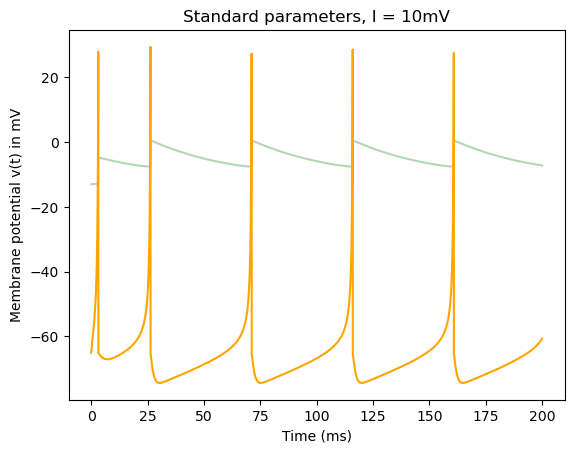

In [5]:
plt.title('Standard parameters, I = 10mV')
Simulation(I=10).run()

<h3>4.2</h3>
The neuron model exhibits tonic firing behavior.
It fires action potentials continuously while the stimulus is applied. The first two APs occur within 25ms of each other, after that the rate is about 1/45ms)

<h3>4.3</h3>

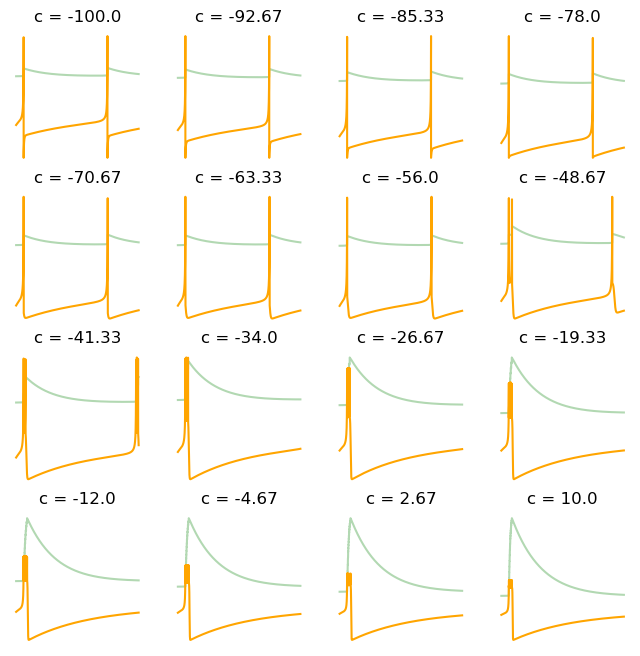

In [627]:
num_plots = 16
plt.figure(figsize=(8,8))

# Different values for c:
c_val = np.linspace(-100, 10, num_plots)
for ii in range(num_plots):
    # Use a lower input current of 4mV
    s = Simulation(I = 4, params = [.02, .2, c_val[ii], 8])

    plots_per_side = int(num_plots ** .5)
    plt.subplot(plots_per_side, plots_per_side, ii + 1)
    plt.title(f"c = {round(c_val[ii], 2)}")
    plt.axis('off')
    s.run()

Parameter c sets the reset voltage at the end of the spike.
Around a value of -50 to -40, the neuron starts to fire  bursts of spikes followed by stronger hyperpolarization phases; when the value for c gets larger, the lowest voltage during hyperpolarization drops below -100mV

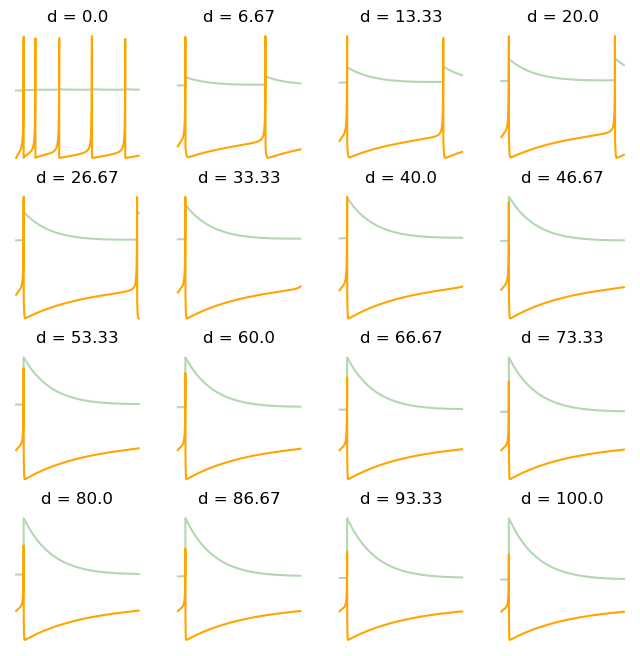

In [628]:
num_plots = 16
plt.figure(figsize=(8,8))

d_val = np.linspace(0, 100, num_plots)
for ii in range(num_plots):
    s = Simulation(I = 4, params = [.02, .2, -65, d_val[ii]])

    plots_per_side = int(num_plots ** .5)
    plt.subplot(plots_per_side, plots_per_side, ii + 1)
    plt.title(f"d = {round(d_val[ii], 2)}")
    plt.axis('off')
    s.run()

The parameter d affects how strongly each spike influences the recovery variable u. Higher values for d make it harder for subsequent spikes to fire because the recovery variable u hasn't decayed enough yet.

<h3>4.4</h3>
Lowest input current needed to create a spike:

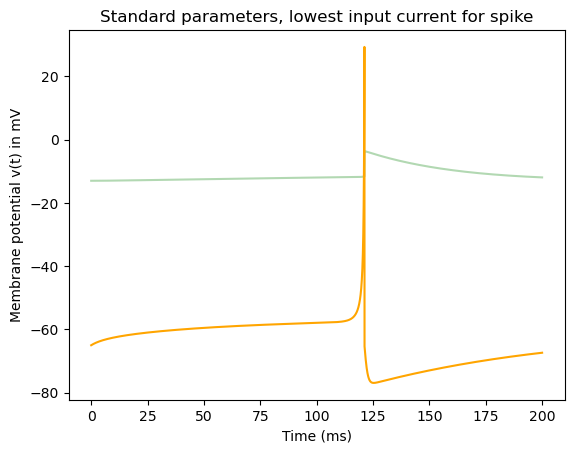

In [629]:
plt.title('Standard parameters, lowest input current for spike')
Simulation(I_threshold).run()

For very low input currents, the neuron doesn't fire.
As the current increases, the spike frequency increases as well. Also, the first few spikes fire with a larger frequency for large input currents.

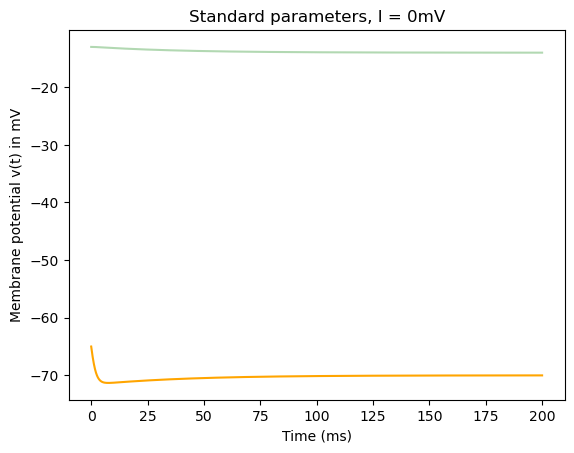

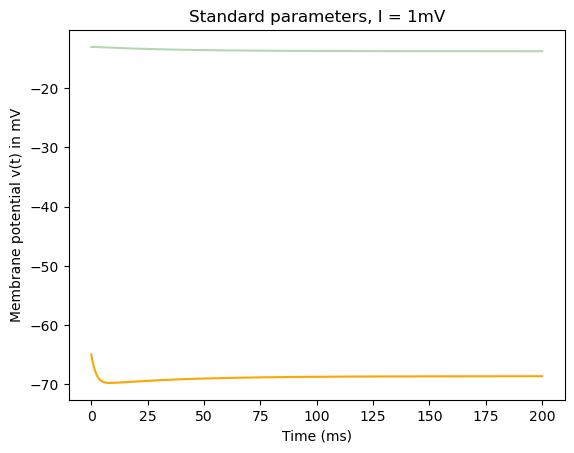

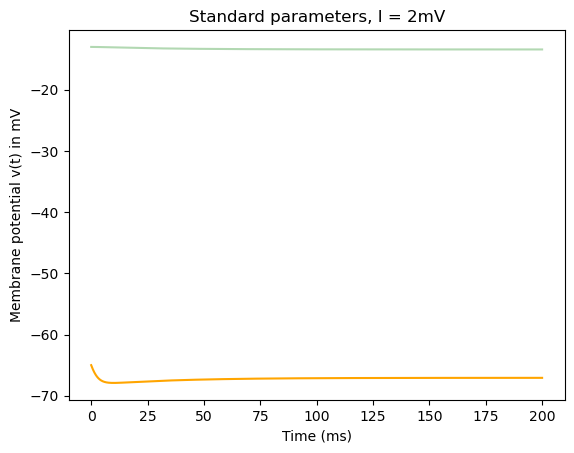

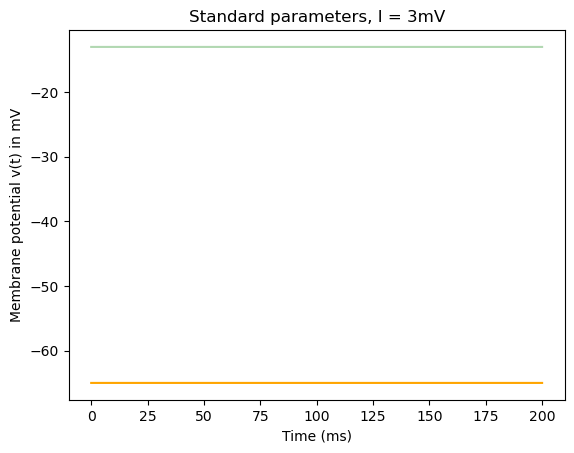

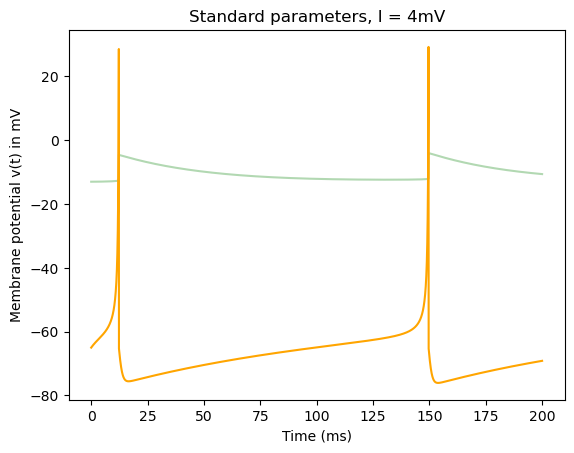

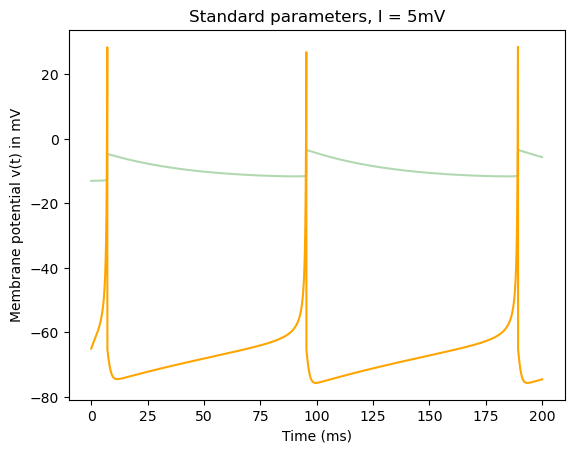

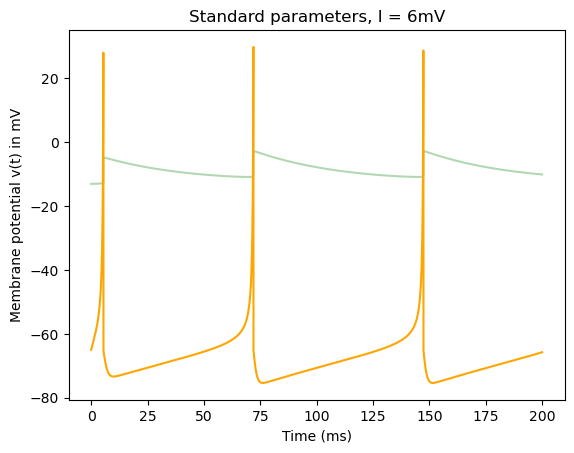

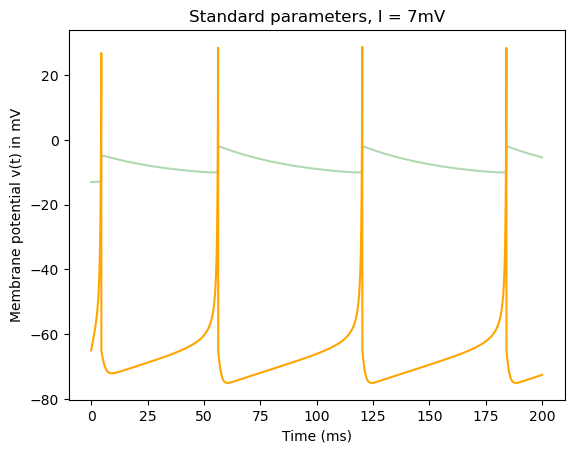

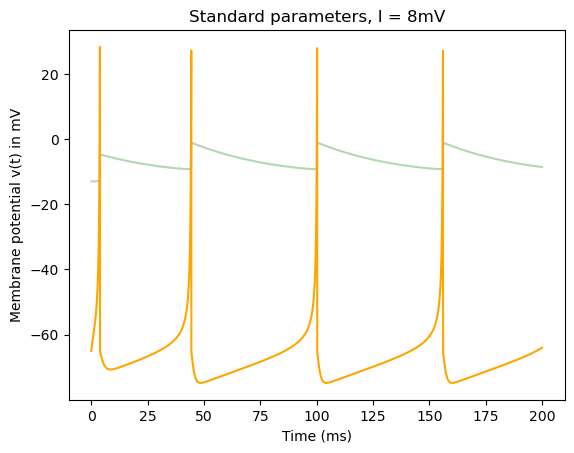

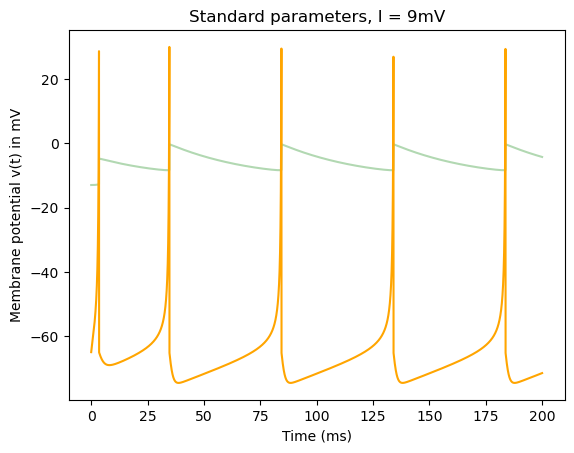

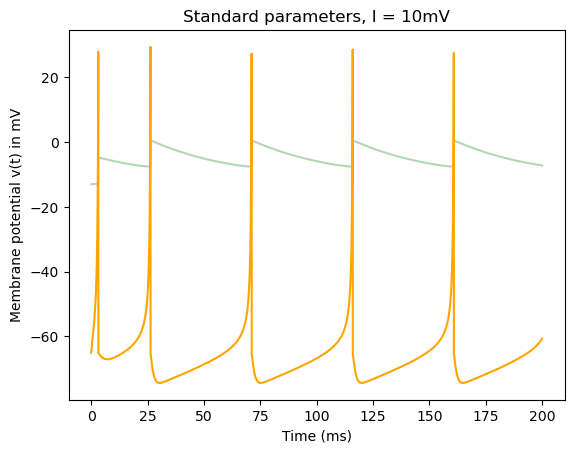

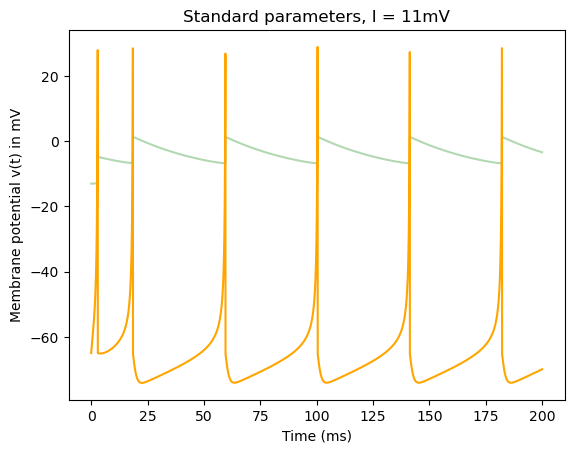

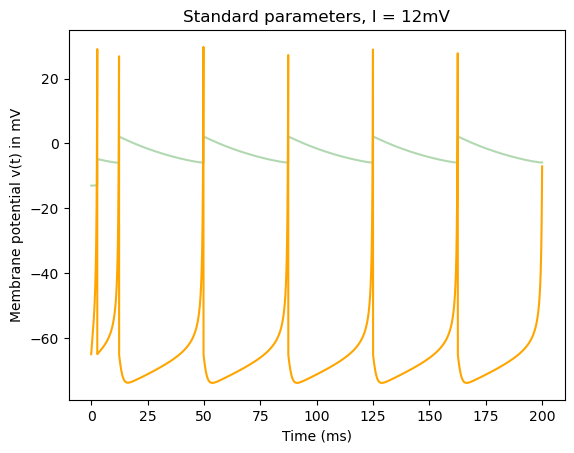

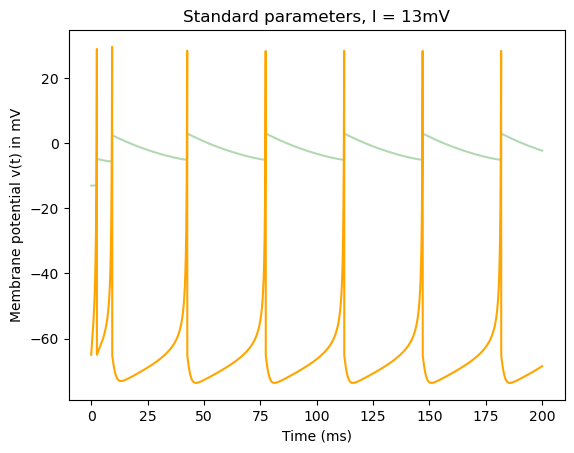

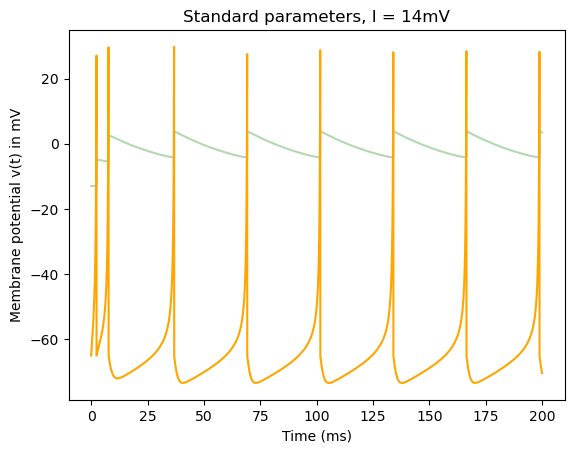

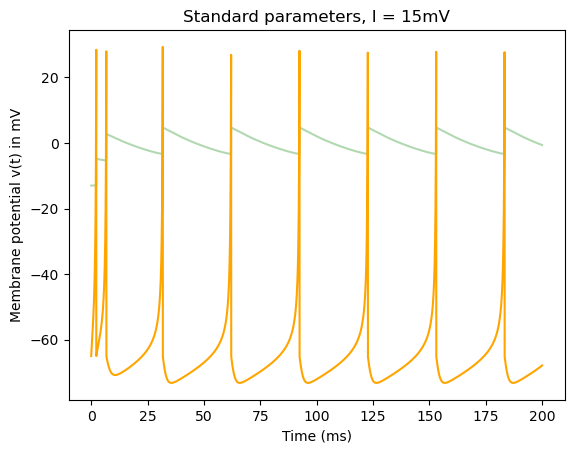

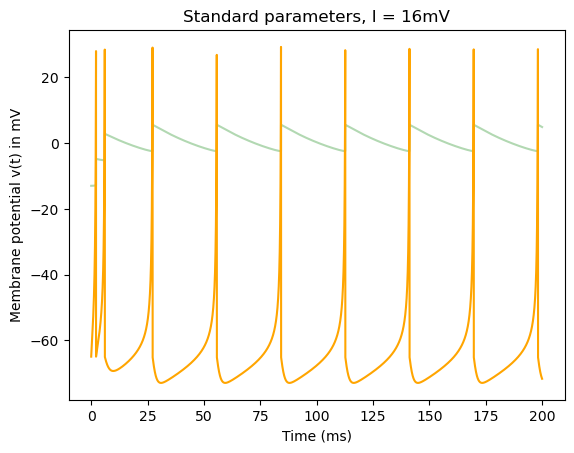

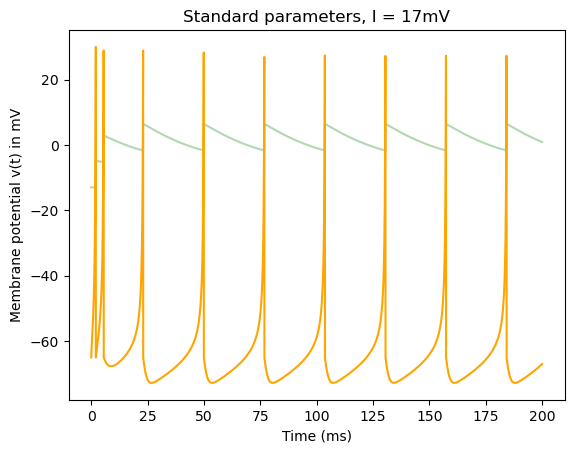

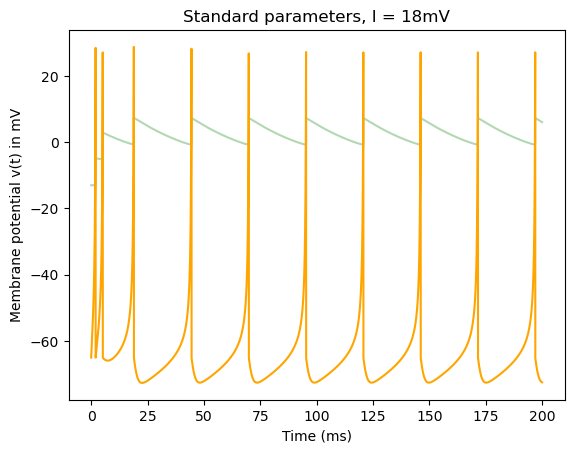

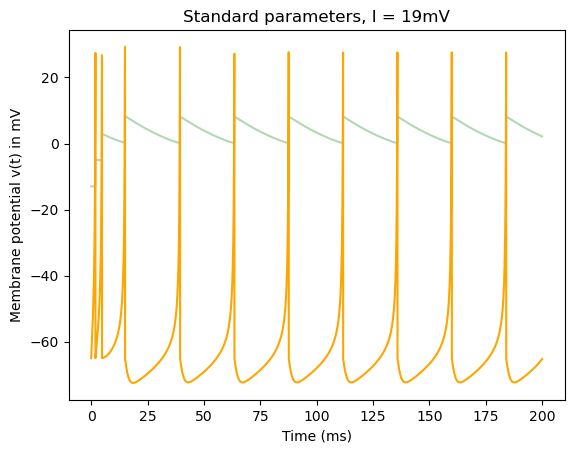

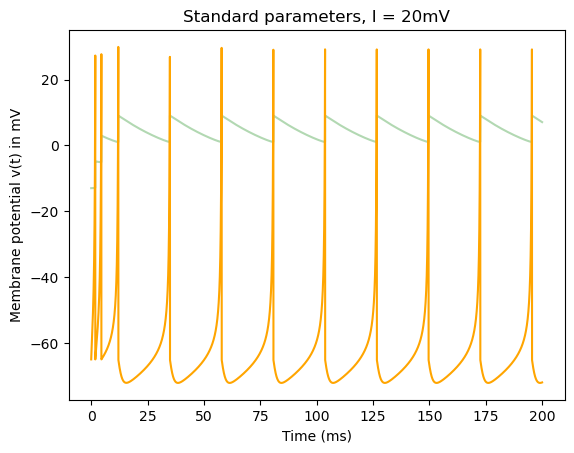

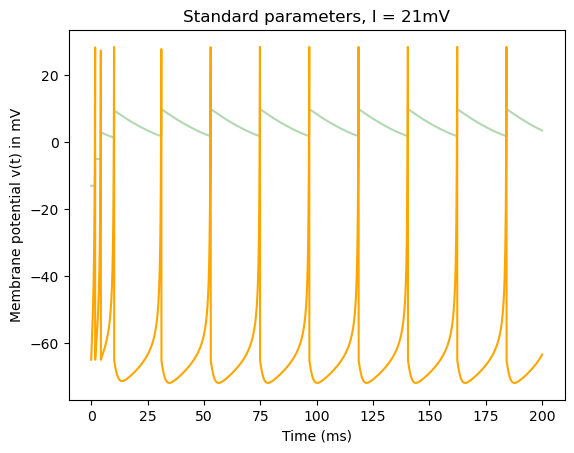

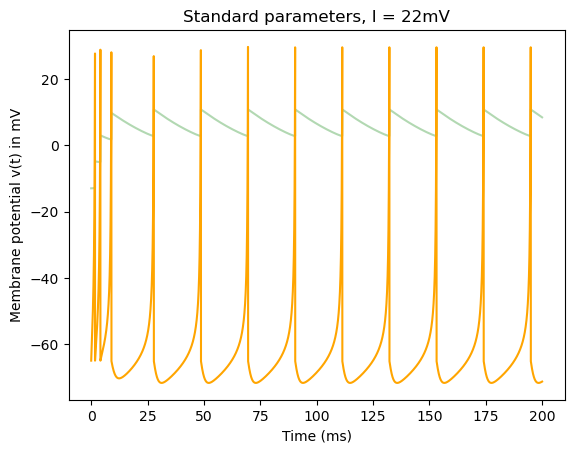

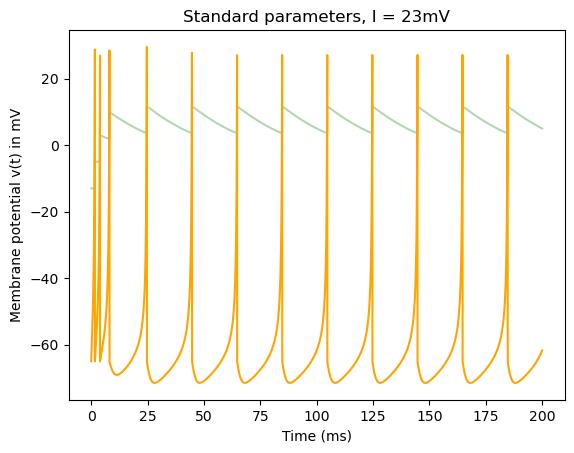

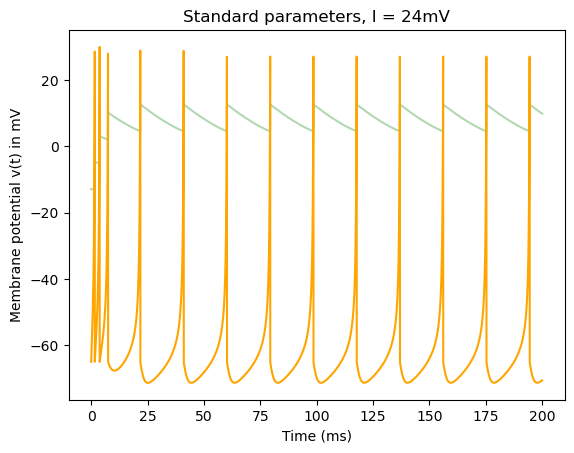

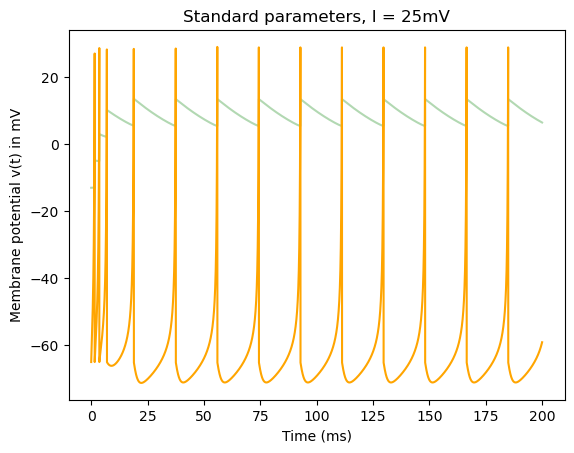

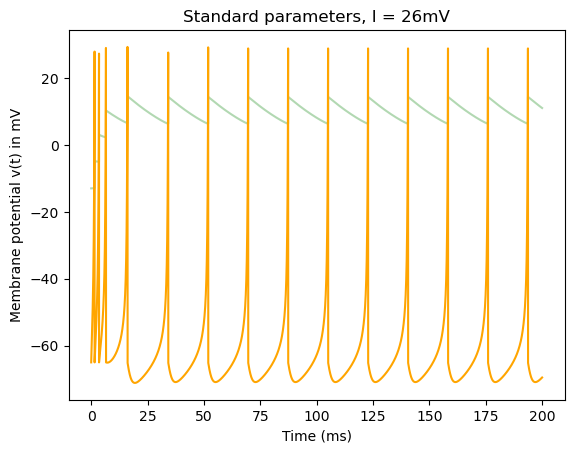

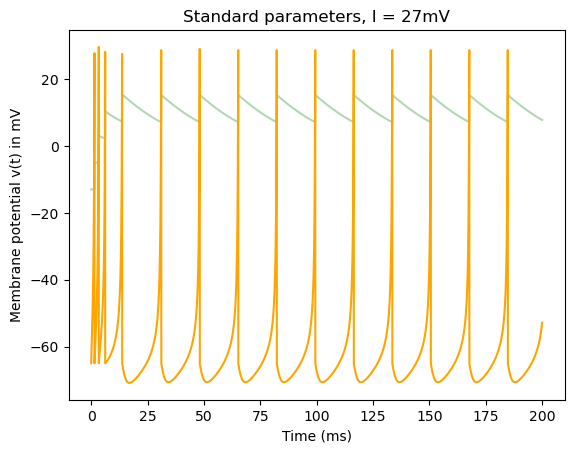

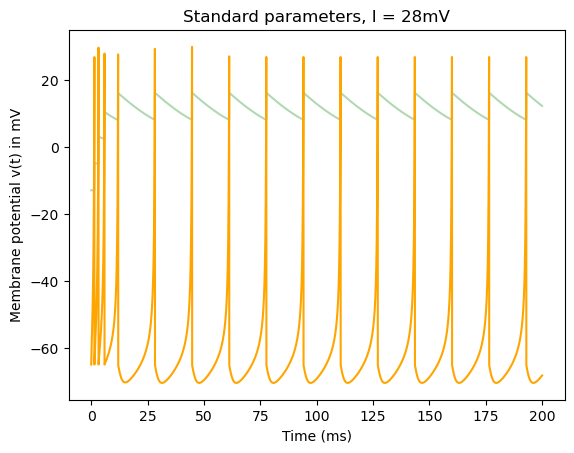

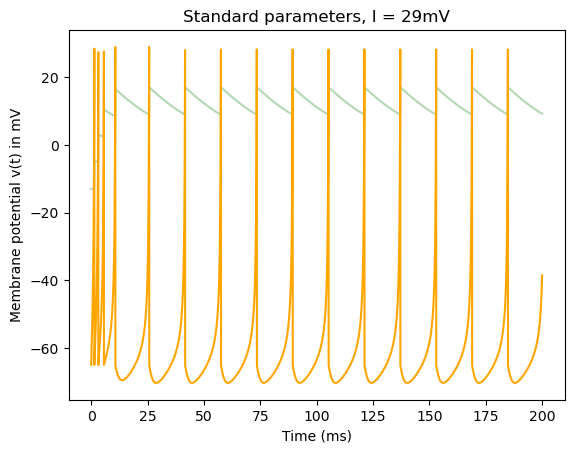

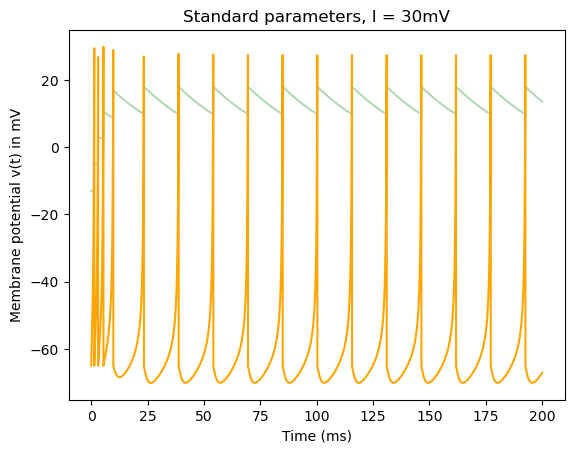

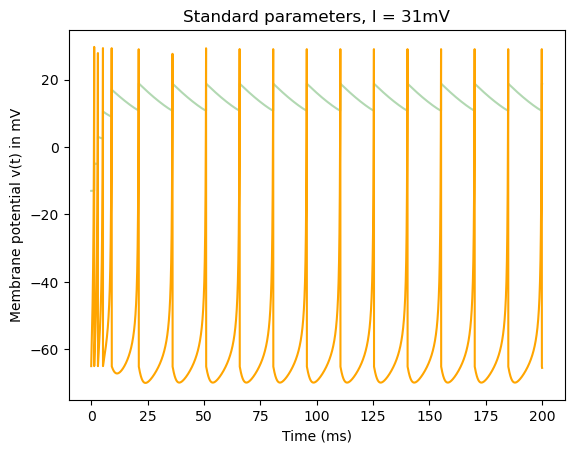

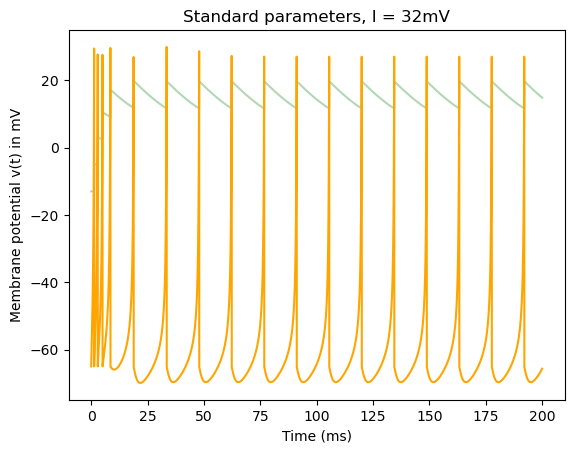

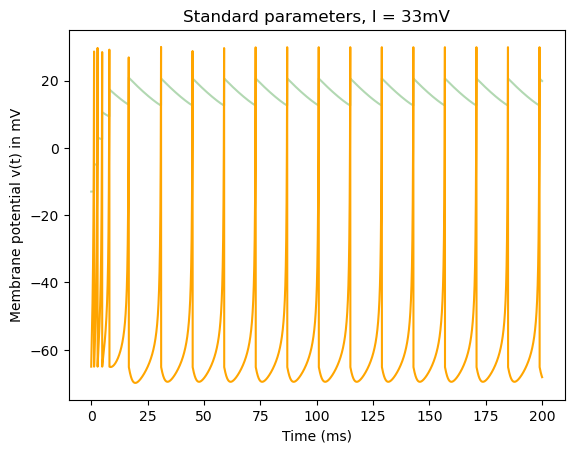

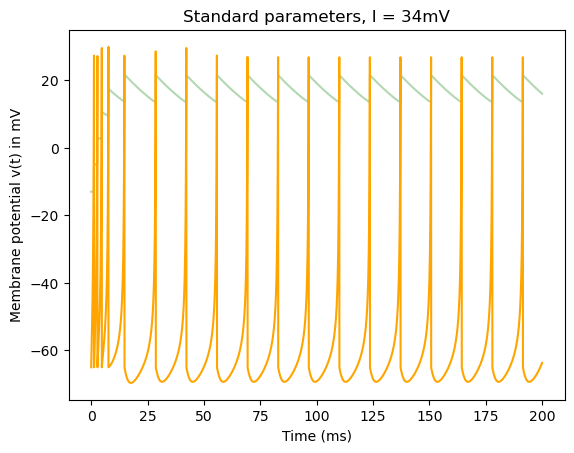

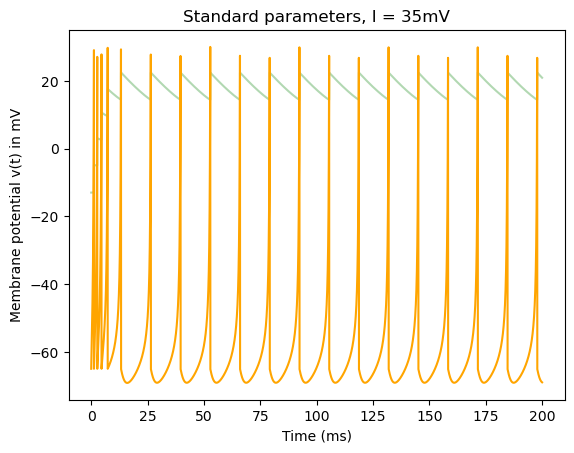

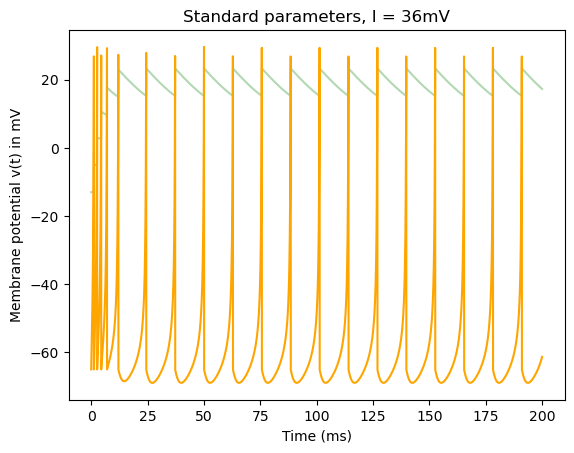

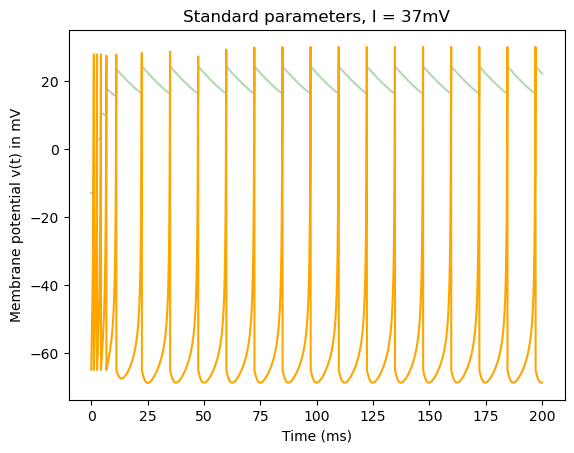

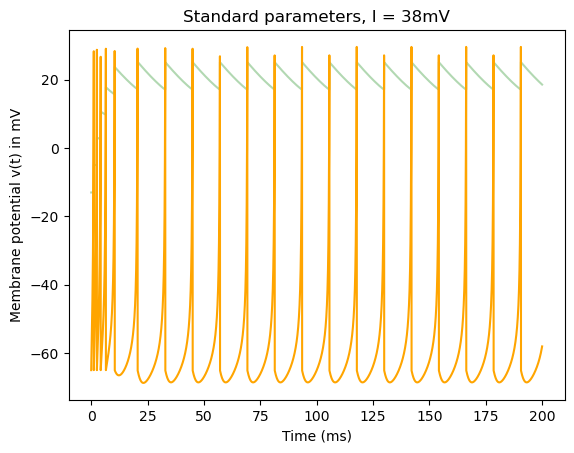

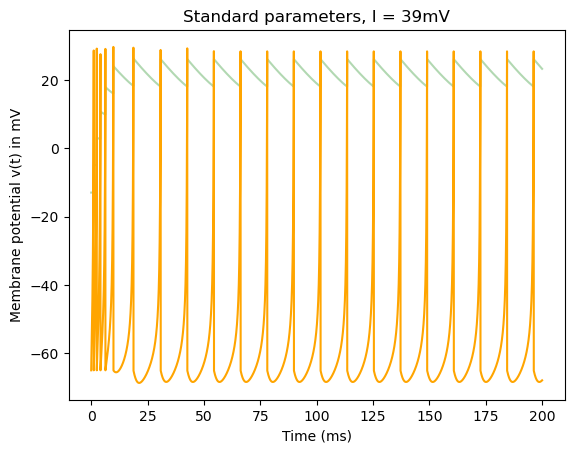

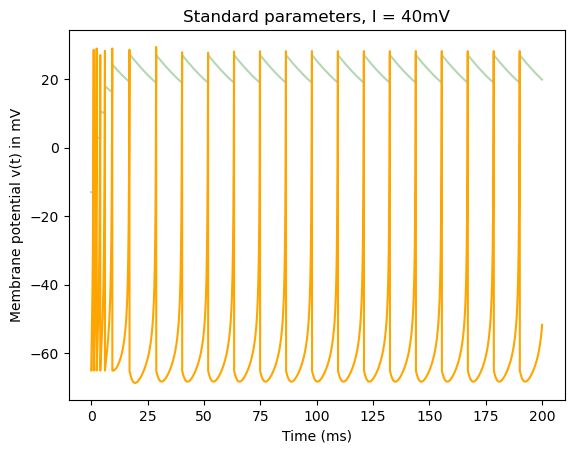

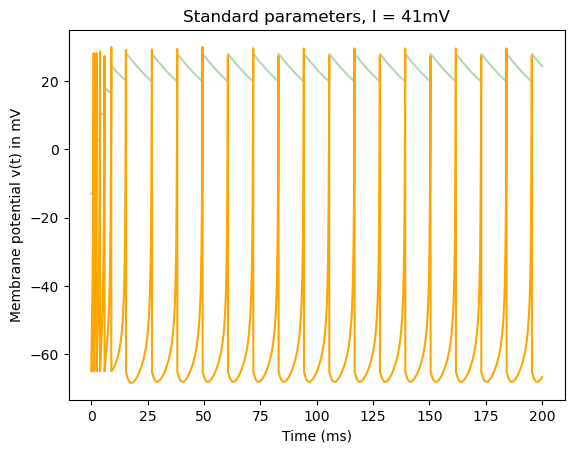

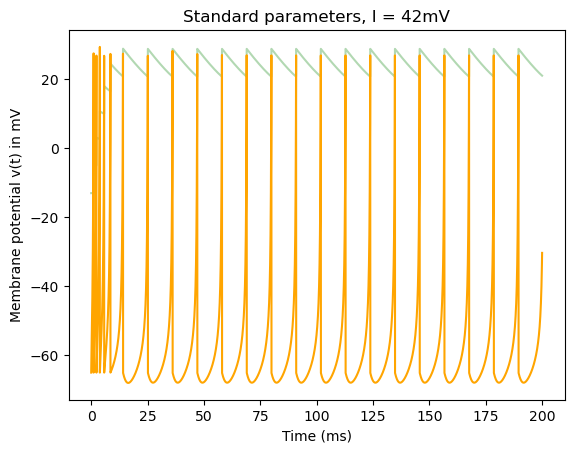

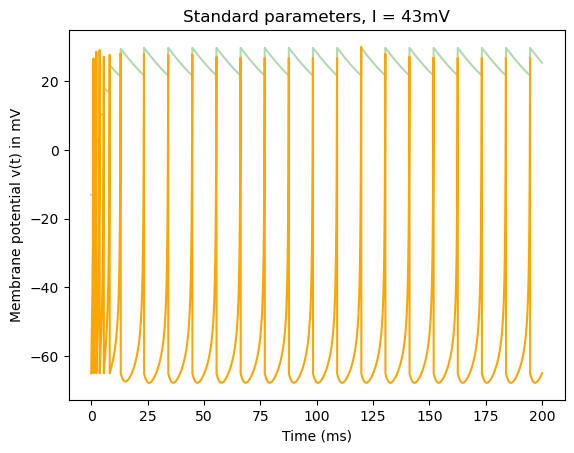

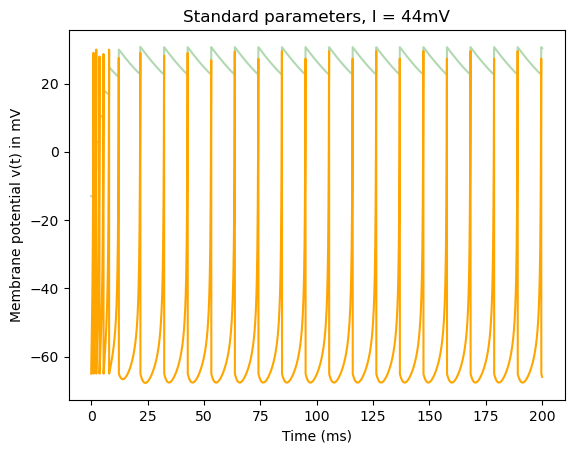

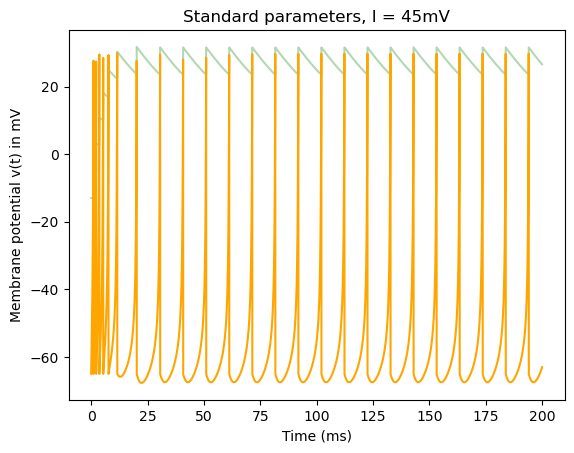

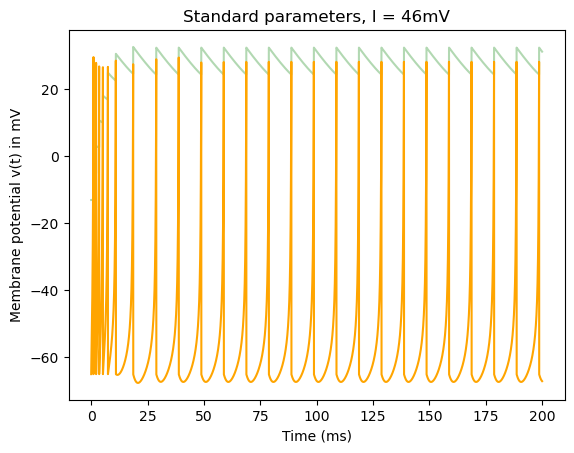

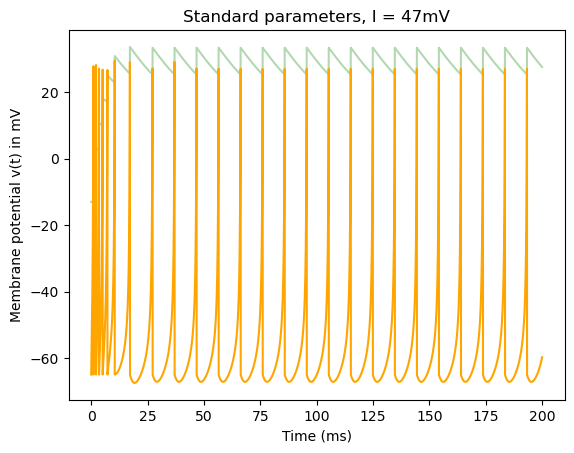

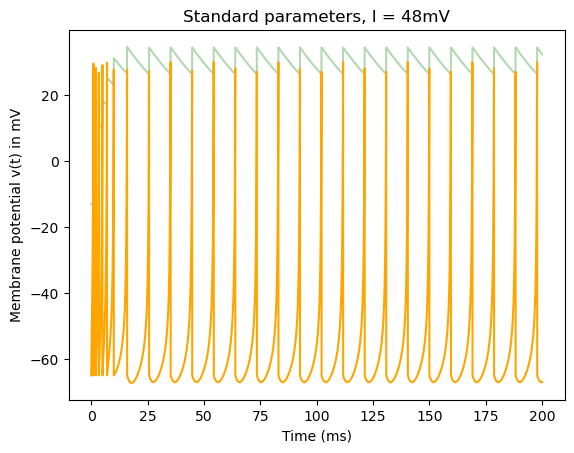

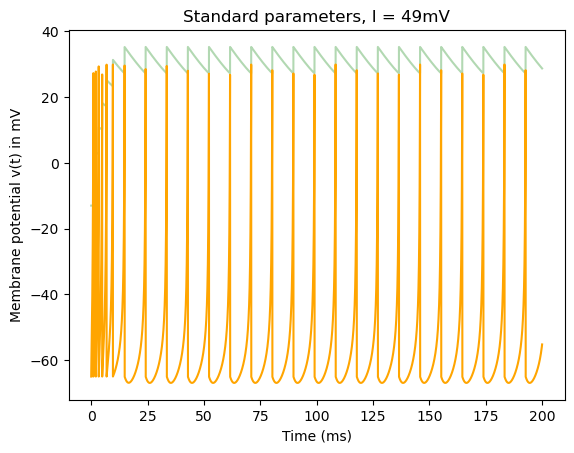

In [630]:
for ii in range(50):
    Simulation(ii).run()
    plt.title(f'Standard parameters, I = {ii}mV')
    plt.show()